использование Tensorflow

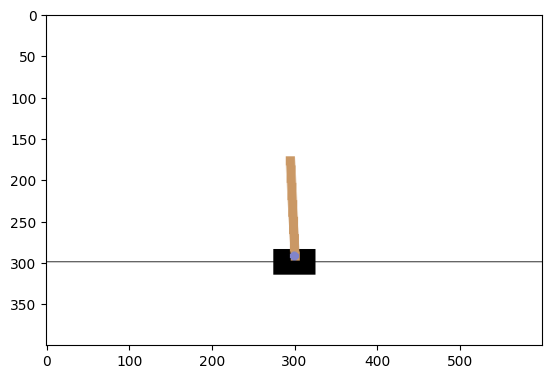

In [1]:
import sys, os
if not os.environ.get("DISPLAY"):
    os.environ['DISPLAY'] = ':1'

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()

n_actions = env.action_space.n
state_dim = env.observation_space.shape

frame = env.render()
plt.imshow(frame)
plt.show()

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()
sess = tf.compat.v1.InteractiveSession()

In [3]:
network = keras.Sequential([
    L.Input(shape=state_dim),
    L.Dense(64, activation='relu'),
    L.Dense(64, activation='relu'),
    L.Dense(int(n_actions), activation='linear')
])

states_input = tf.compat.v1.placeholder(
    tf.float32, shape=(None,) + state_dim, name='states_input'
)
q_values = network(states_input)

sess.run(tf.compat.v1.global_variables_initializer())

In [4]:
def get_action(state, epsilon=0):
    q_vals = sess.run(q_values, feed_dict={states_input: [state]})[0]
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    return np.argmax(q_vals)

проверка

In [5]:
assert network.output_shape == (None, n_actions)
assert network.layers[-1].activation == keras.activations.linear

s, _ = env.reset()
assert np.shape(get_action(s)) == ()

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for i in range(10000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 10000 * (eps / n_actions)) < 200
    print('e=%.1f tests passed' % eps)

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


Q-обучение через градиентный спуск

In [6]:
# плейсхолдеры для кортежа (s, a, r, s', done)
states_ph = tf.compat.v1.placeholder(tf.float32, shape=(None,) + state_dim)
actions_ph = tf.compat.v1.placeholder(tf.int32, shape=[None])
rewards_ph = tf.compat.v1.placeholder(tf.float32, shape=[None])
next_states_ph = tf.compat.v1.placeholder(tf.float32, shape=(None,) + state_dim)
is_done_ph = tf.compat.v1.placeholder(tf.bool, shape=[None])

# Q-значения для всех действий в текущем состоянии
predicted_qvalues = network(states_ph)

# Q-значение только для выбранного действия
predicted_qvalues_for_actions = tf.reduce_sum(
    predicted_qvalues * tf.one_hot(actions_ph, n_actions), axis=1
)

gamma = 0.99

# Q-значения для следующих состояний
predicted_next_qvalues = network(next_states_ph)

# V*(s') = max_a Q(s', a)
next_state_values = tf.reduce_max(predicted_next_qvalues, axis=1)

# целевое значение: r + gamma * V*(s')
target_qvalues_for_actions = rewards_ph + gamma * next_state_values

# для терминальных состояний: Q(s,a) = r
target_qvalues_for_actions = tf.where(
    is_done_ph, rewards_ph, target_qvalues_for_actions
)

In [7]:
# MSE loss
loss = tf.reduce_mean(
    (predicted_qvalues_for_actions - tf.stop_gradient(target_qvalues_for_actions)) ** 2
)
train_step = tf.compat.v1.train.AdamOptimizer(1e-4).minimize(loss)

assert tf.gradients(loss, [predicted_qvalues_for_actions])[0] is not None, \
    "убедитесь, что обновляете q-значения для выбранных действий"
assert tf.gradients(loss, [predicted_next_qvalues])[0] is None, \
    "убедитесь, что не распространяете градиент через Q(s', a')"
assert predicted_next_qvalues.shape.ndims == 2, \
    "убедитесь, что предсказали q-значения для всех действий в следующем состоянии"
assert next_state_values.shape.ndims == 1, \
    "V(s') должно быть одномерным (максимум только по действиям)"
assert target_qvalues_for_actions.shape.ndims == 1, \
    "целевые значения должны быть вектором"

In [8]:
sess.run(tf.compat.v1.global_variables_initializer())

def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()

    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            sess.run(train_step, feed_dict={
                states_ph: [s],
                actions_ph: [a],
                rewards_ph: [r],
                next_states_ph: [next_s],
                is_done_ph: [done]
            })

        total_reward += r
        s = next_s
        if done:
            break

    return total_reward

epsilon = 0.5
for epoch in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    mean_rew = np.mean(session_rewards)
    print(f"epoch #{epoch}:\tmean reward = {mean_rew:.3f}\tepsilon = {epsilon:.3f}")

    epsilon *= 0.99
    assert epsilon >= 1e-4

    if mean_rew > 300:
        print("You Win!")
        break

epoch #0:	mean reward = 13.820	epsilon = 0.500
epoch #1:	mean reward = 13.650	epsilon = 0.495
epoch #2:	mean reward = 13.680	epsilon = 0.490
epoch #3:	mean reward = 14.570	epsilon = 0.485
epoch #4:	mean reward = 13.120	epsilon = 0.480
epoch #5:	mean reward = 14.720	epsilon = 0.475
epoch #6:	mean reward = 13.260	epsilon = 0.471
epoch #7:	mean reward = 14.610	epsilon = 0.466
epoch #8:	mean reward = 14.120	epsilon = 0.461
epoch #9:	mean reward = 14.260	epsilon = 0.457
epoch #10:	mean reward = 18.740	epsilon = 0.452
epoch #11:	mean reward = 14.830	epsilon = 0.448
epoch #12:	mean reward = 22.080	epsilon = 0.443
epoch #13:	mean reward = 20.300	epsilon = 0.439
epoch #14:	mean reward = 21.590	epsilon = 0.434
epoch #15:	mean reward = 29.500	epsilon = 0.430
epoch #16:	mean reward = 45.490	epsilon = 0.426
epoch #17:	mean reward = 45.810	epsilon = 0.421
epoch #18:	mean reward = 52.280	epsilon = 0.417
epoch #19:	mean reward = 54.200	epsilon = 0.413
epoch #20:	mean reward = 73.880	epsilon = 0.409
ep

использование pytorch

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_dim[0], 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        return self.layers(x)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = DQN(state_dim, n_actions).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()

In [11]:
def get_action(state, epsilon=0):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)

    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        q_vals = network(state_tensor).cpu().numpy()[0]
    return int(np.argmax(q_vals))

In [12]:
# проверка архитектуры
test_state, _ = env.reset()
test_out = network(torch.FloatTensor(test_state).unsqueeze(0).to(device))
assert test_out.shape == (1, n_actions), "модель должна возвращать Q-значения для каждого действия"

# проверка epsilon-greedy
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "должно возвращаться одно действие"

for eps in [0., 0.1, 0.5, 1.0]:
    freq = np.bincount([get_action(s, epsilon=eps) for _ in range(10000)], minlength=n_actions)
    best = freq.argmax()
    assert abs(freq[best] - 10000 * (1 - eps + eps / n_actions)) < 200
    for other in range(n_actions):
        if other != best:
            assert abs(freq[other] - 10000 * (eps / n_actions)) < 200
    print(f'e={eps:.1f} tests passed')

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [13]:
gamma = 0.99

def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()

    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            s_tensor = torch.FloatTensor(s).unsqueeze(0).to(device)
            a_tensor = torch.LongTensor([a]).to(device)
            r_tensor = torch.FloatTensor([r]).to(device)

            # Q(s, a) для выбранного действия
            q_predicted = network(s_tensor).gather(1, a_tensor.unsqueeze(1)).squeeze()

            if done:
                q_target = r_tensor
            else:
                next_tensor = torch.FloatTensor(next_s).unsqueeze(0).to(device)
                with torch.no_grad():
                    q_target = r_tensor + gamma * network(next_tensor).max(dim=1)[0]

            loss = mse_loss(q_predicted, q_target.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += r
        s = next_s
        if done:
            break

    return total_reward

In [14]:
epsilon = 0.5
for epoch in range(1000):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    mean_rew = np.mean(session_rewards)
    print(f"epoch #{epoch}:\tmean reward = {mean_rew:.3f}\tepsilon = {epsilon:.3f}")

    epsilon *= 0.99
    assert epsilon >= 1e-4

    if mean_rew > 300:
        print("You Win!")
        break

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


epoch #0:	mean reward = 14.850	epsilon = 0.500
epoch #1:	mean reward = 14.380	epsilon = 0.495
epoch #2:	mean reward = 14.520	epsilon = 0.490
epoch #3:	mean reward = 13.320	epsilon = 0.485
epoch #4:	mean reward = 14.800	epsilon = 0.480
epoch #5:	mean reward = 14.260	epsilon = 0.475
epoch #6:	mean reward = 16.570	epsilon = 0.471
epoch #7:	mean reward = 23.580	epsilon = 0.466
epoch #8:	mean reward = 18.610	epsilon = 0.461
epoch #9:	mean reward = 34.410	epsilon = 0.457
epoch #10:	mean reward = 34.560	epsilon = 0.452
epoch #11:	mean reward = 38.400	epsilon = 0.448
epoch #12:	mean reward = 51.670	epsilon = 0.443
epoch #13:	mean reward = 56.190	epsilon = 0.439
epoch #14:	mean reward = 67.120	epsilon = 0.434
epoch #15:	mean reward = 74.040	epsilon = 0.430
epoch #16:	mean reward = 78.330	epsilon = 0.426
epoch #17:	mean reward = 82.470	epsilon = 0.421
epoch #18:	mean reward = 94.010	epsilon = 0.417
epoch #19:	mean reward = 111.900	epsilon = 0.413
epoch #20:	mean reward = 141.210	epsilon = 0.409
